# Safe_AgriLab - Phase 3 : Entraînement de l'Intelligence Artificielle
Dans ce notebook, nous évaluons les performances de notre modèle **Random Forest Regressor**.
L'objectif était de prédire le Rendement Agricole (kg/ha) en évitant le surapprentissage (overfitting), grâce à notre **Indice de Stress Climatique**.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")

# Chargement des données et du modèle
df = pd.read_csv('../data/master_dataset/Togo_Agriculture_Augmented_Data.csv')
pipeline = joblib.load('../models/random_forest_model.pkl')

features = ['Produit', 'Indice_Stress_Climatique', 'RH2M', 'GWETROOT']
target = 'Rendement_kg_ha'

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

y_pred_test = pipeline.predict(X_test)
r2 = r2_score(y_test, y_pred_test)

print(f"R² Score sur les données de Test : {r2:.4f}")


R² Score sur les données de Test : 0.8908


## 1. Précision des Prédictions (Réel vs Prédit)
Si le modèle est bon, les points se rapprocheront d'une ligne diagonale parfaite.


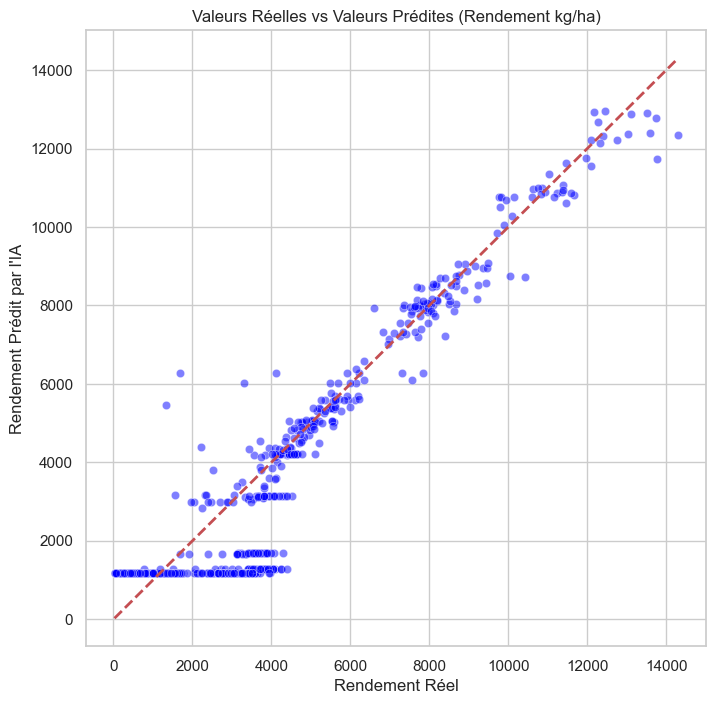

In [2]:
plt.figure(figsize=(8, 8))
sns.scatterplot(x=y_test, y=y_pred_test, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Valeurs Réelles vs Valeurs Prédites (Rendement kg/ha)')
plt.xlabel('Rendement Réel')
plt.ylabel('Rendement Prédit par l\'IA')
plt.show()


## 2. Importance des Variables (Feature Importance)
Qu'est-ce que l'IA regarde pour prendre sa décision ?


In [ ]:
# Extraction de l'importance depuis le pipeline
model = pipeline.named_steps['model']
preprocessor = pipeline.named_steps['preprocessor']

# Les noms des cultures encodées
cat_encoder = preprocessor.named_transformers_['cat']
cat_features = cat_encoder.get_feature_names_out(['Produit'])

# On rassemble tous les noms (Cultures + variables numériques)
all_features = list(cat_features) + ['Indice_Stress_Climatique', 'RH2M', 'GWETROOT']
importances = model.feature_importances_

# Création d'un DataFrame pour trier
df_imp = pd.DataFrame({
    'Feature': all_features,
    'Importance': importances
})

# On regroupe toutes les cultures sous "Type de Plante" pour que le graphique soit lisible
type_plante_imp = df_imp[df_imp['Feature'].str.contains('Produit_')]['Importance'].sum()
df_imp_clean = pd.DataFrame({
    'Feature': ['Type de Plante (Produit)', 'Indice_Stress_Climatique', 'RH2M', 'GWETROOT'],
    'Importance': [type_plante_imp, 
                   df_imp[df_imp['Feature'] == 'Indice_Stress_Climatique']['Importance'].values[0],
                   df_imp[df_imp['Feature'] == 'RH2M']['Importance'].values[0],
                   df_imp[df_imp['Feature'] == 'GWETROOT']['Importance'].values[0]]
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_imp_clean, x='Importance', y='Feature', palette='viridis')
plt.title('Ce qui influence la décision de l\'IA')
plt.show()
